## Correlation Matrix Visualization

#### Manan Verma
#### 03 June, 2025

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

According to the Global Industry Classification Standard (GICS), every publicly traded stock on the stock market falls into one of 11 sectors:
- Communication Services
- Consumer Discretionary 
- Consumer Staples
- Financials
- Energy
- Health Care
- Industrials
- Information Technology
- Materials
- Real Estate
- Utilities

Below, the returns of one stock from each of the above sectors will be visualized.

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


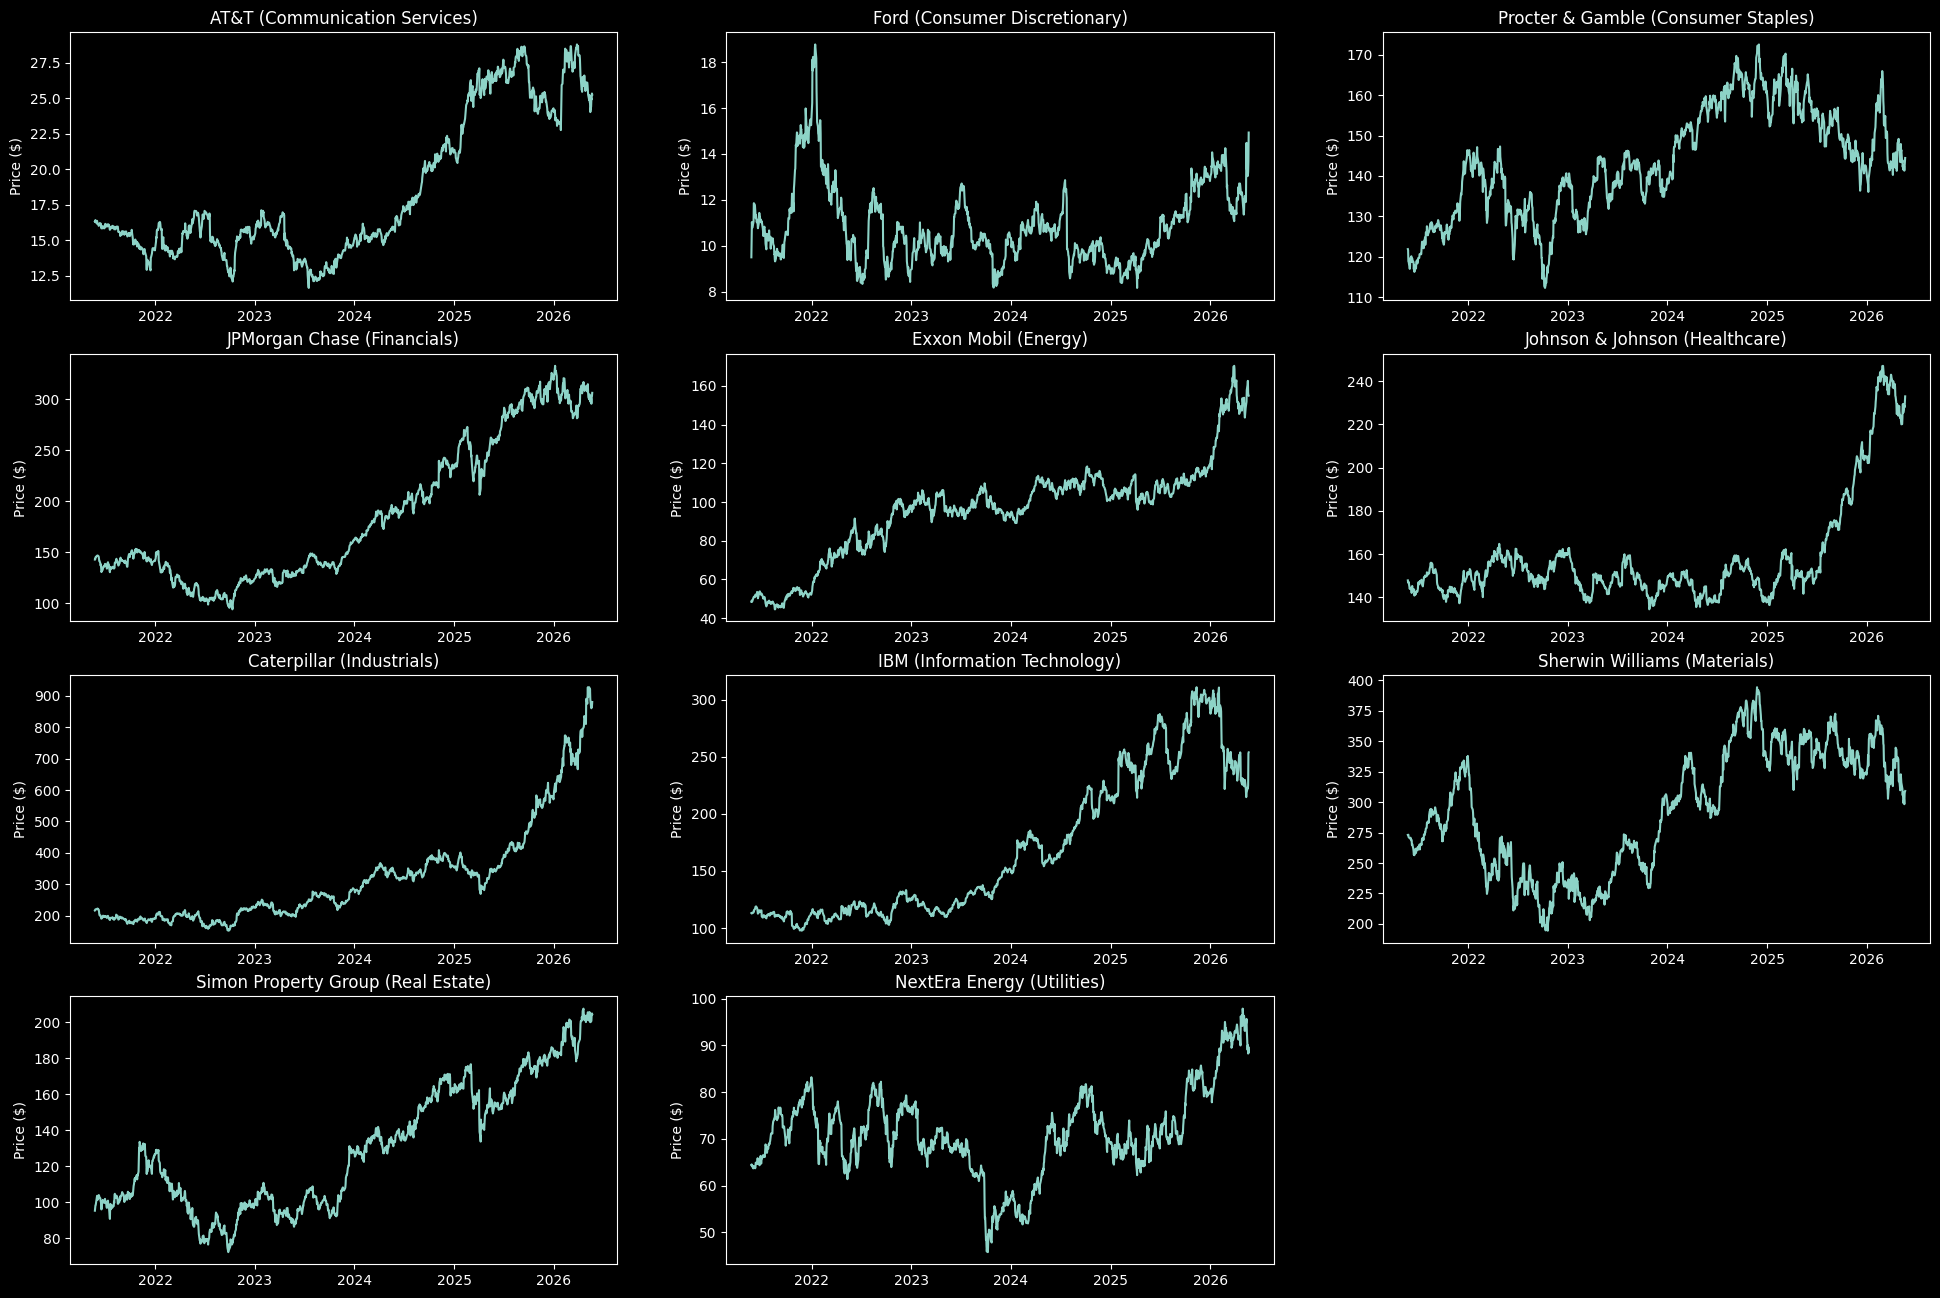

In [2]:
#Visualize a stock from each of the above sectors

att_data = yf.download('T', start = '2021-05-25', end = '2026-05-25')       #Communication Services
ford_data = yf.download('F', start = '2021-05-25', end = '2026-05-25')      #Consumer Discretionary
pg_data = yf.download('PG', start = '2021-05-25', end = '2026-05-25')       #Consumer Staples
jpm_data = yf.download('JPM', start = '2021-05-25', end = '2026-05-25')     #Financials
exxon_data = yf.download('XOM', start = '2021-05-25', end = '2026-05-25')   #Energy
jj_data = yf.download('JNJ', start = '2021-05-25', end = '2026-05-25')      #Healthcare
cat_data = yf.download('CAT', start = '2021-05-25', end = '2026-05-25')     #Industrials
ibm_data = yf.download('IBM', start = '2021-05-25', end = '2026-05-25')     #Information Technology
sherwin_data = yf.download('SHW', start = '2021-05-25', end = '2026-05-25') #Materials
simon_data = yf.download('SPG', start = '2021-05-25', end = '2026-05-25')   #Real Estate
nextera_data = yf.download('NEE', start = '2021-05-25', end = '2026-05-25') #Utilities

#Plot all of the stock prices over time
plt.style.use("dark_background")
fig, ax = plt.subplots(4, 3, figsize = (24, 16))
ax[0, 0].plot(att_data['Close'])
ax[0, 0].set_ylabel("Price ($)")
ax[0, 0].set_title("AT&T (Communication Services)")

ax[0, 1].plot(ford_data['Close'])
ax[0, 1].set_ylabel("Price ($)")
ax[0, 1].set_title("Ford (Consumer Discretionary)")

ax[0, 2].plot(pg_data['Close'])
ax[0, 2].set_ylabel("Price ($)")
ax[0, 2].set_title("Procter & Gamble (Consumer Staples)")

ax[1, 0].plot(jpm_data['Close'])
ax[1, 0].set_ylabel("Price ($)")
ax[1, 0].set_title("JPMorgan Chase (Financials)")

ax[1, 1].plot(exxon_data['Close'])
ax[1, 1].set_ylabel("Price ($)")
ax[1, 1].set_title("Exxon Mobil (Energy)")

ax[1, 2].plot(jj_data['Close'])
ax[1, 2].set_ylabel("Price ($)")
ax[1, 2].set_title("Johnson & Johnson (Healthcare)")

ax[2, 0].plot(cat_data['Close'])
ax[2, 0].set_ylabel("Price ($)")
ax[2, 0].set_title("Caterpillar (Industrials)")

ax[2, 1].plot(ibm_data['Close'])
ax[2, 1].set_ylabel("Price ($)")
ax[2, 1].set_title("IBM (Information Technology)")

ax[2, 2].plot(sherwin_data['Close'])
ax[2, 2].set_ylabel("Price ($)")
ax[2, 2].set_title("Sherwin Williams (Materials)")

ax[3, 0].plot(simon_data['Close'])
ax[3, 0].set_ylabel("Price ($)")
ax[3, 0].set_title("Simon Property Group (Real Estate)")

ax[3, 1].plot(nextera_data['Close'])
ax[3, 1].set_ylabel("Price ($)")
ax[3, 1].set_title("NextEra Energy (Utilities)")

ax[3, 2].remove()

plt.show()

***

Now, a correlation matrix between the daily returns of all of these stocks will be visualized.

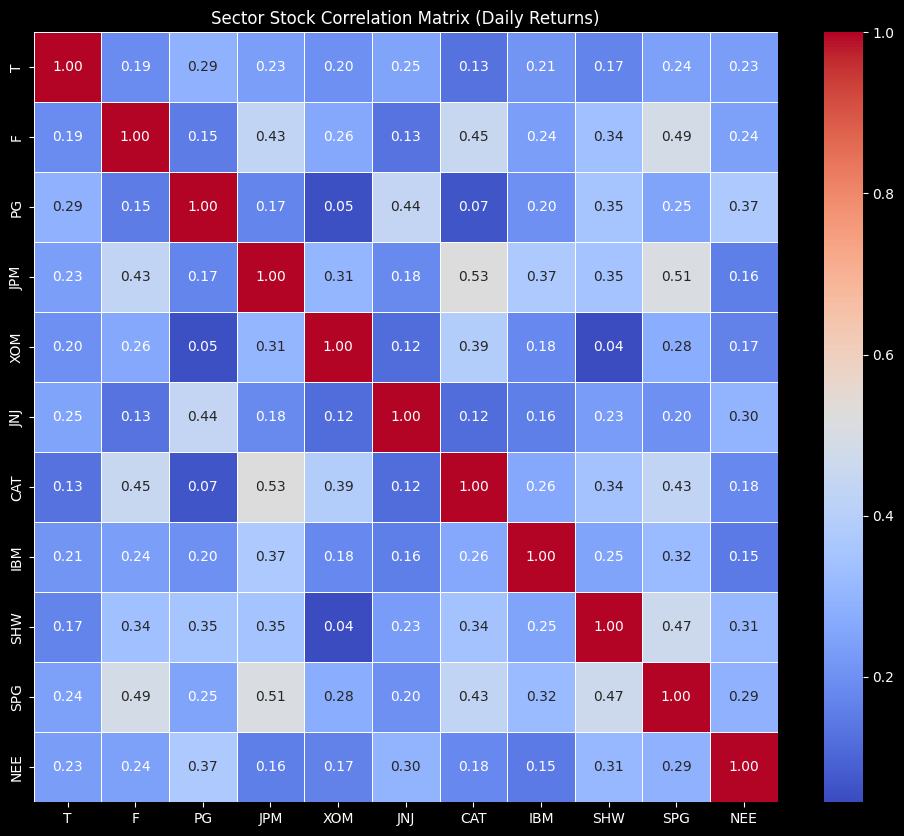

In [3]:
#Create correlation matrix of returns and visualize

prices = pd.concat({
    'T': att_data['Close']['T'],
    'F': ford_data['Close']['F'],
    'PG': pg_data['Close']['PG'],
    'JPM': jpm_data['Close']['JPM'],
    'XOM': exxon_data['Close']['XOM'],
    'JNJ': jj_data['Close']['JNJ'],
    'CAT': cat_data['Close']['CAT'],
    'IBM': ibm_data['Close']['IBM'],
    'SHW': sherwin_data['Close']['SHW'],
    'SPG': simon_data['Close']['SPG'],
    'NEE': nextera_data['Close']['NEE']
}, axis=1)

returns = prices.pct_change().dropna()
corr_matrix = returns.corr()

plt.figure(figsize = (12, 10))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = ".2f", linewidths = 0.5)
plt.title('Sector Stock Correlation Matrix (Daily Returns)')
plt.show()


Based on the heatmap generated, it can be seen that the stocks with the greatest correlation appear to be:  
- Caterpillar (*Industrials*) & JPMorgan Chase (*Financials*)
- Simon Property Group (*Real Estate*) & JPMorgan Chase (*Financials*)
- Simon Property Group (*Real Estate*) & Ford (*Consumer Discretionary*)
- Simon Property Group (*Real Estate*) & Sherwin Williams (*Materials*)
- Caterpillar (*Industrials*) & Ford (*Consumer Discretionary*)

However, it cannot be discerned that there is a clear trend, here. To come to a stronger conclusion about the correlation between these sectors, 5 different stocks from each of the sectors will be and evaluated against each other.

***

For **Financials**, the additional stocks to be evaluated will be:
- Bank of America (*BAC*)
    * Consumer retail banking, commercial lending
- Berkshire Hathaway (*BRK.B*)
    * Insurance, financial holdings
- Visa (*V*)
    * Digital transaction processing, transaction networks
- Goldman Sachs (*GS*)
    * Investment banking, global trading
- BlackRock (*BLK*)
    * Institutional asset management, investment platforms

For **Real Estate**, the additional stocks to be evaluated will be:
- American Tower Corp. (*AMT*)
    * Specialized telecom
- Prologis (*PLD*)
    * Industrial real estate, logistics warehouses
- Equinix (*EQIX*)
    * Data center technology real estate
- AvalonBay Communities (*AVB*)
    * Residential real estate
- Realty Income Corp (*O*)
    * Retail real estate

For **Consumer Discretionary**, the additional stocks to be evaluated will be:
- Amazon (*AMZN*)
    * E-commerce
- Home Depot (*HD*)
    * Housing-related retail
- McDonald's (*MCD*)
    * Fast-food restaurants
- General Motors (*GM*)
    * Automotive manufacturing
- Nike (*NKE*)
    * Apparel

For **Industrials**, the additional stocks to be evaluated will be:
- GE Aerospace (*GE*)
    * Commercial and military aircraft
- Deere Co. (*DE*)
    * Agricultural machinery, heavy construction equipment
- RTX Corp. (*RTX*)
    * Aerospace and defense
- Boeing (*BA*)
    * Aerospace manufacturing, defense
- Eaton Corporation (*ETN*)
    * Power management

For **Materials**, the additional stocks to be evaluated will be:
- Linde (*LIN*)
    * Atmospheric and process gasses provider
- BHP Group (*BHP*)
    * Extraction and processing of minerals
- Freeport-McMoRan (*FCX*)
    * Mining, copper production
- Ecolab Inc. (*ECL*)
    * Water, hygiene, and energy technologies and services
- Amcor plc (*AMCR*)
    * Development and production of packaging

[*********************100%***********************]  5 of 5 completed


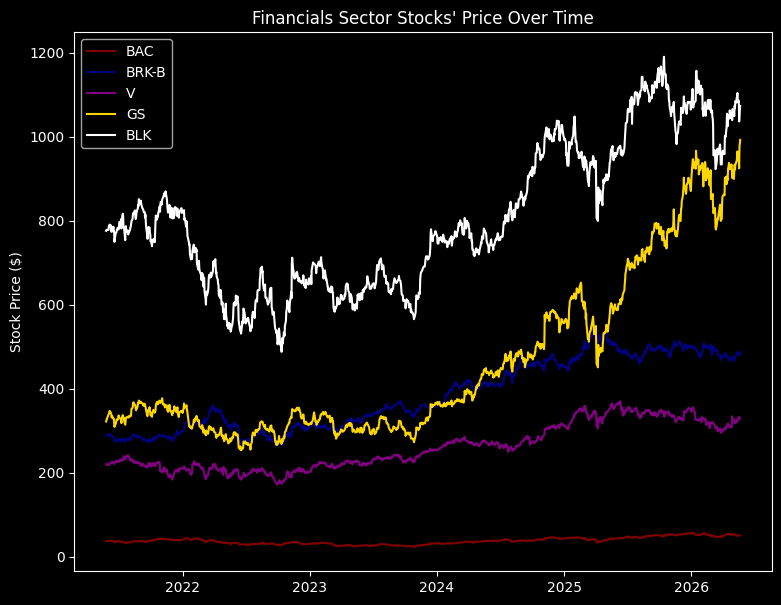

[*********************100%***********************]  5 of 5 completed


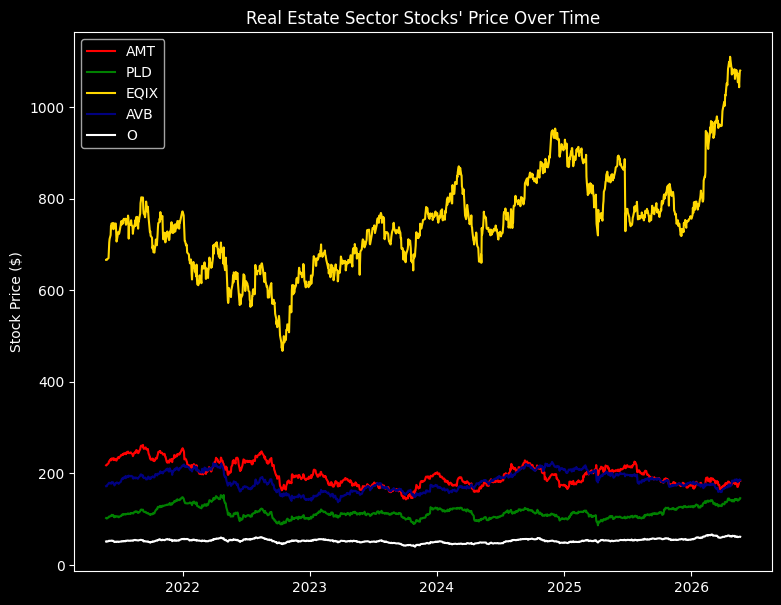

[*********************100%***********************]  5 of 5 completed


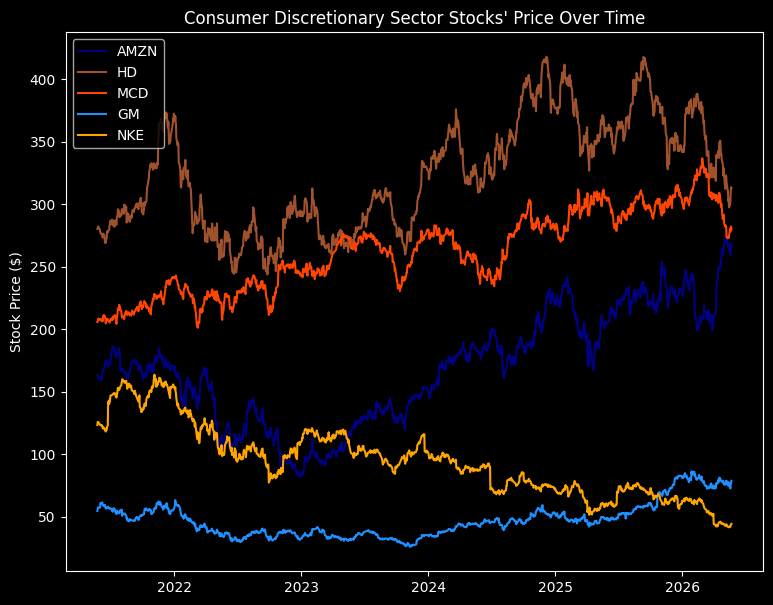

[*********************100%***********************]  5 of 5 completed


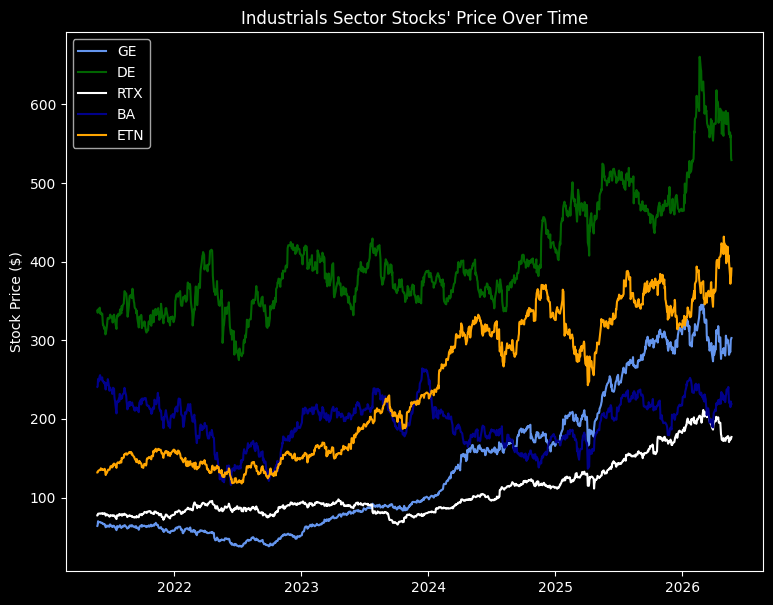

[*********************100%***********************]  5 of 5 completed


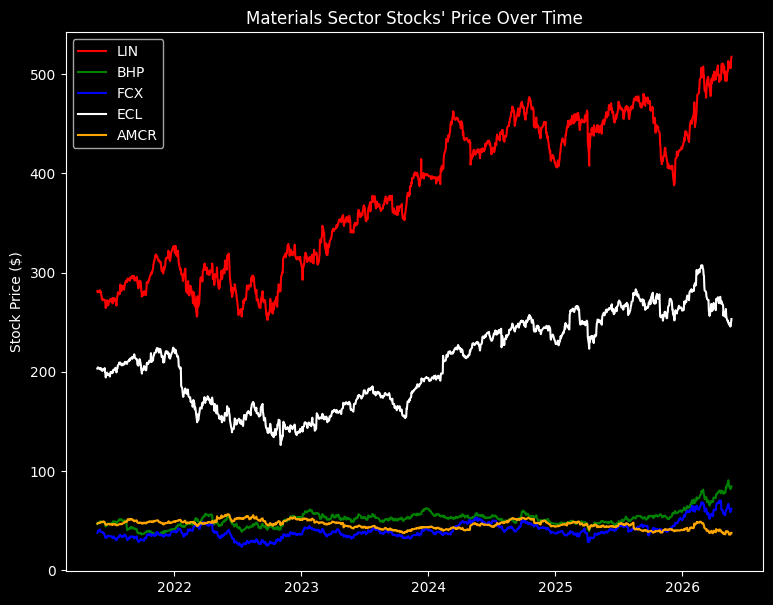

In [4]:
#Visualize intra-sector stock returns

#Financials Sector
financial_stocks = [['BAC', 'BRK-B', 'V', 'GS', 'BLK'], ['maroon', 'navy', 'purple', 'gold', 'white']]
financial_stocks_data = yf.download(financial_stocks[0], start = '2021-05-25', end = '2026-05-25')
plt.figure(figsize = (9, 7))
for stock, color in zip(financial_stocks[0], financial_stocks[1]):
    plt.plot(financial_stocks_data['Close'][stock], color = color, label = stock)
plt.legend()
plt.title('Financials Sector Stocks\' Price Over Time')
plt.ylabel('Stock Price ($)')
plt.show()

#Real Estate Sector
real_estate_stocks = [['AMT', 'PLD', 'EQIX', 'AVB', 'O'], ['red', 'green', 'gold', 'navy', 'white']]
real_estate_stocks_data = yf.download(real_estate_stocks[0], start = '2021-05-25', end = '2026-05-25')
plt.figure(figsize = (9, 7))
for stock, color in zip(real_estate_stocks[0], real_estate_stocks[1]):
    plt.plot(real_estate_stocks_data['Close'][stock], color = color, label = stock)
plt.legend()
plt.title('Real Estate Sector Stocks\' Price Over Time')
plt.ylabel('Stock Price ($)')
plt.show()

#Consumer Discretionary Sector
consumer_disc_stocks = [['AMZN', 'HD', 'MCD', 'GM', 'NKE'], ['navy', 'sienna', 'orangered', 'dodgerblue', 'orange']]
consumer_disc_stocks_data = yf.download(consumer_disc_stocks[0], start = '2021-05-25', end = '2026-05-25')
plt.figure(figsize = (9, 7))
for stock, color in zip(consumer_disc_stocks[0], consumer_disc_stocks[1]):
    plt.plot(consumer_disc_stocks_data['Close'][stock], color = color, label = stock)
plt.legend()
plt.title('Consumer Discretionary Sector Stocks\' Price Over Time')
plt.ylabel('Stock Price ($)')
plt.show()

#Industrials Sector
industrials_stocks = [['GE', 'DE', 'RTX', 'BA', 'ETN'], ['cornflowerblue', 'darkgreen', 'white', 'darkblue', 'orange']]
industrials_stocks_data = yf.download(industrials_stocks[0], start = '2021-05-25', end = '2026-05-25')
plt.figure(figsize = (9, 7))
for stock, color in zip(industrials_stocks[0], industrials_stocks[1]):
    plt.plot(industrials_stocks_data['Close'][stock], color = color, label = stock)
plt.legend()
plt.title('Industrials Sector Stocks\' Price Over Time')
plt.ylabel('Stock Price ($)')
plt.show()

#Materials Sector
materials_stocks = [['LIN', 'BHP', 'FCX', 'ECL', 'AMCR'], ['red', 'green', 'blue', 'white', 'orange']]
materials_stocks_data = yf.download(materials_stocks[0], start = '2021-05-25', end = '2026-05-25')
plt.figure(figsize = (9, 7))
for stock, color in zip(materials_stocks[0], materials_stocks[1]):
    plt.plot(materials_stocks_data['Close'][stock], color = color, label = stock)
plt.legend()
plt.title('Materials Sector Stocks\' Price Over Time')
plt.ylabel('Stock Price ($)')
plt.show()

Below, *intra-sector* return correlations will be visualized:

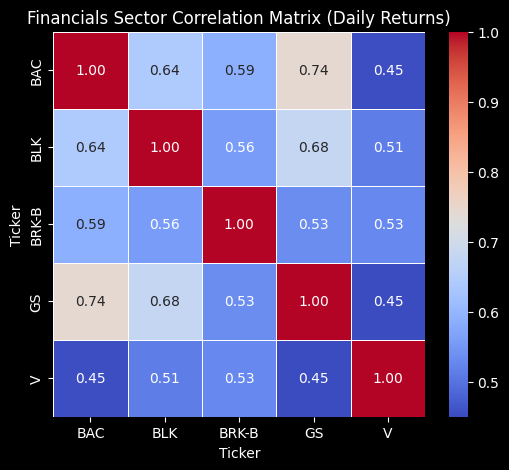

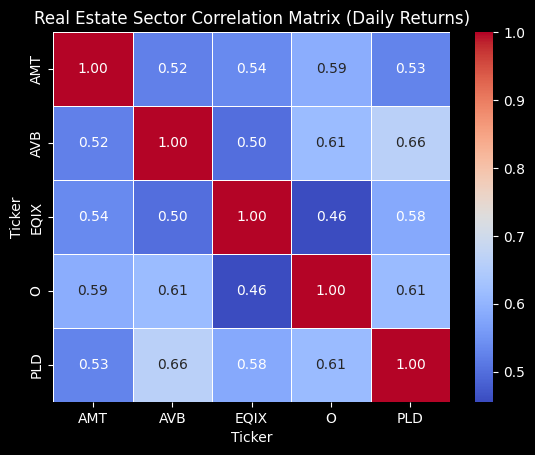

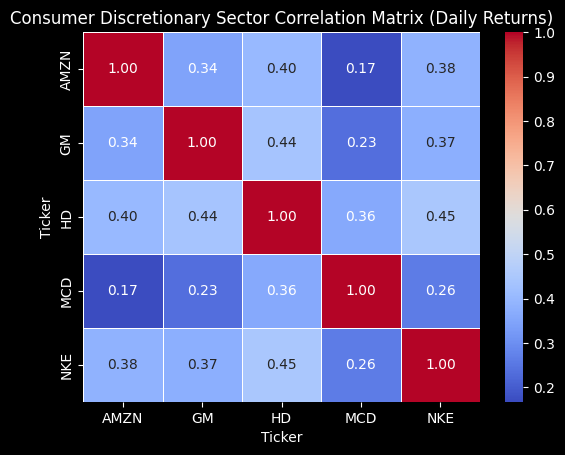

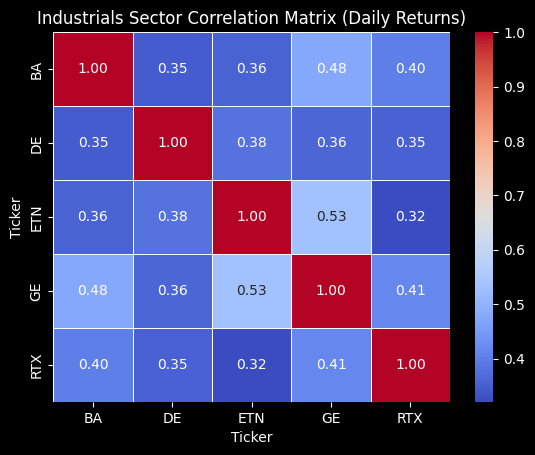

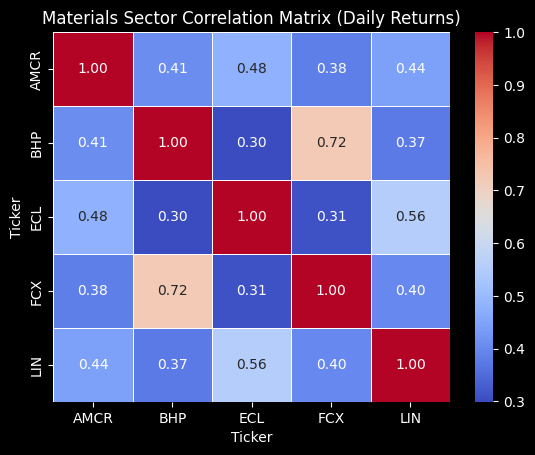

In [5]:
#Visualize intra-sector correlations via correlation matrices

financials_corr_matrix = financial_stocks_data['Close'].pct_change().dropna().corr()
real_estate_corr_matrix = real_estate_stocks_data['Close'].pct_change().dropna().corr()
consumer_disc_corr_matrix = consumer_disc_stocks_data['Close'].pct_change().dropna().corr()
industrials_corr_matrix = industrials_stocks_data['Close'].pct_change().dropna().corr()
materials_corr_matrix = materials_stocks_data['Close'].pct_change().dropna().corr()

matrices = [[financials_corr_matrix, real_estate_corr_matrix, consumer_disc_corr_matrix, industrials_corr_matrix, materials_corr_matrix],
            ['Financials', 'Real Estate', 'Consumer Discretionary', 'Industrials', 'Materials']]

plt.figure(figsize = (6, 5))
for matrix, sector in zip(matrices[0], matrices[1]): 
    sns.heatmap(matrix, annot = True, cmap = 'coolwarm', fmt = ".2f", linewidths = 0.5)
    plt.title(f'{sector} Sector Correlation Matrix (Daily Returns)', wrap = True)
    plt.show()

Below, *inter-sector* correlations that had been previously been identified with the highest correlations will be visualized.
Remember, the groupings were:
- Industrials & Financials
- Real Estate & Financials
- Real Estate & Consumer Discretionary
- Real Estate & Materials
- Industrials & Consumer Discretionary 

To do this, an **equal-weighted sector returns series** will be used. Essentially, the daily returns are averaged among the five stocks within the sector, for every day. Then, the correlation between those two lists is found.

In [6]:
#Visualize inter-sector correlations

ind_fin_corr = industrials_stocks_data['Close'].pct_change().dropna().mean(axis = 1).corr(financial_stocks_data['Close'].pct_change().dropna().mean(axis = 1))
real_fin_corr = real_estate_stocks_data['Close'].pct_change().dropna().mean(axis = 1).corr(financial_stocks_data['Close'].pct_change().dropna().mean(axis = 1))
real_cons_corr = real_estate_stocks_data['Close'].pct_change().dropna().mean(axis = 1).corr(consumer_disc_stocks_data['Close'].pct_change().dropna().mean(axis = 1))
real_mat_corr = real_estate_stocks_data['Close'].pct_change().dropna().mean(axis = 1).corr(materials_stocks_data['Close'].pct_change().dropna().mean(axis = 1))
ind_cons_corr = industrials_stocks_data['Close'].pct_change().dropna().mean(axis = 1).corr(consumer_disc_stocks_data['Close'].pct_change().dropna().mean(axis = 1))

print(f"""Industrials vs Financials: {ind_fin_corr:.4f}
Real Estate vs Financials: {real_fin_corr:.4f}
Real Estate vs Materials: {real_mat_corr:.4f}
Industrials vs Consumer Discretionary: {ind_cons_corr:.4f}
Real Estate vs Consumer Discretionary: {real_cons_corr:.4f}""")

Industrials vs Financials: 0.7029
Real Estate vs Financials: 0.5431
Real Estate vs Materials: 0.5332
Industrials vs Consumer Discretionary: 0.6247
Real Estate vs Consumer Discretionary: 0.5561


From this surface-level exploration of sector correlations, it seems that the *industrials* and *financials* sectors have the greatest correlation of daily returns.  
However, the methodology used in this notebook is very unscientific. To truly come to a more statistically sound conclusion, it would be pertinent to explore a much more vast set of stocks (including small, mid, and large-cap stocks across as many sub-sectors as possible) and compare them all against each other.  
Using correlations is very important when it comes to portfolio engineering or creating a trading strategy, especially in terms of hedging risk, optimizing expected returns, or identifying hidden risks.

***

### Correlation

In order to understand correlation, knowledge of **covariance** will first be necessary.  
Covariance is a measure of the directional relationship between variables. A positive covariance indicates that the two variable trend in the same direction, and a negative covariance indicates the two variables move in opposite directions. The magnitide of the covariance indicates the strength of the relationship, where a covariance of $0$ indicates no linear relationship. The formula of covariance is:
$$cov(X, Y) = \mathbb{E}[(X - \mathbb{E}[X])(Y - \mathbb{E}[Y])]$$
for two random variables $X$, and $Y$

If both $X$ and $Y$ are above their means (expected values) or both are below their means, then the product of the deviations from the means will be positive. Conversely, if the deviations from the means are of opposite signs, then the product will be negative. Then, the mean of all the products is taken. If the products are primarily positive, then the covariance will be positive, and vice versa.  
There are two main issues with covariance, however: the covariance value is unbounded (i.e., it can output values in the range $(-\infty, \infty)$), and covariance can provide a meaningless relationship if the two variables are measured in different scales.

Thus, **correlation** is used, and is the preferred method for determining a relationship between two random variables. In order to fix the issues with covariance, correlation is calculated by normalizing the covariance by the standard deviations of the variables:
$$corr(X, Y) = \frac{cov(X, Y)}{s_Xs_Y}$$
where $s$ is the sample standard deviation.

Correlation is bounded between -1 (negative correlation) and 1 (positive correlation). It is important to keep in mind, however, that this definition of correlation works *best* for data that is linearly related.

***Note that correlation does not imply causation!!***

***